===== KEY KPIs =====
Total Revenue: 2252607.4127
Average Order Value: 230.1161929410563
Top Sales Region: West
Top Traffic Country: United States


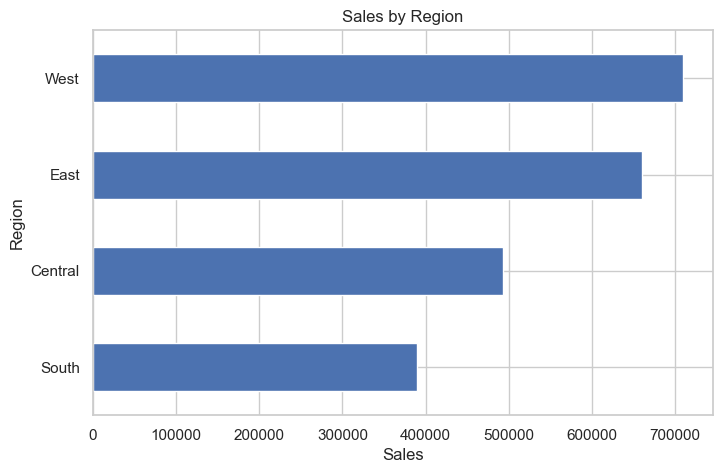

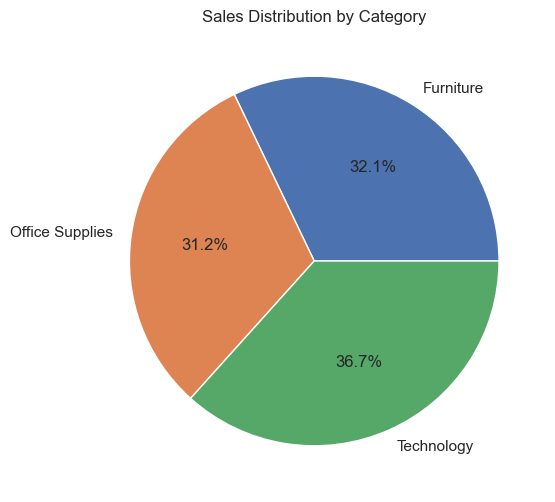

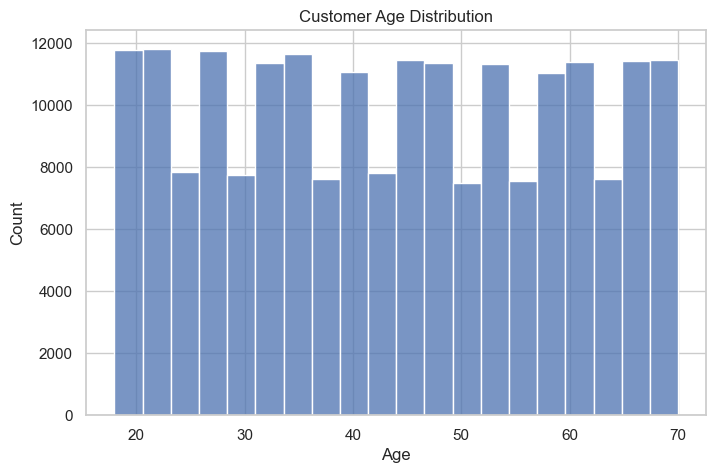

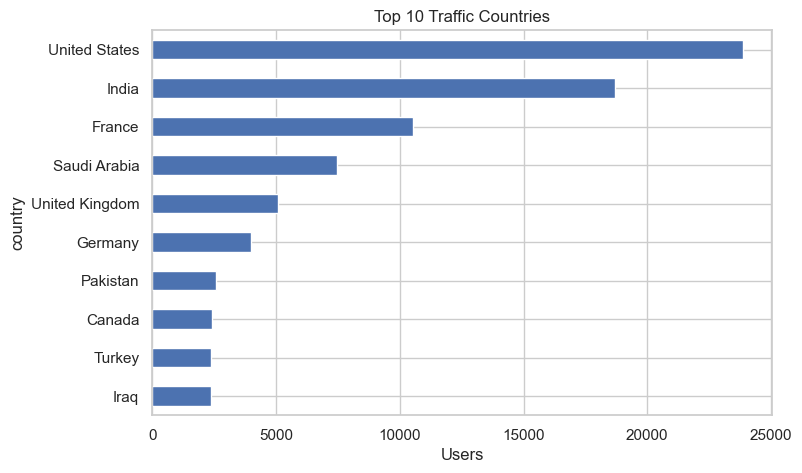

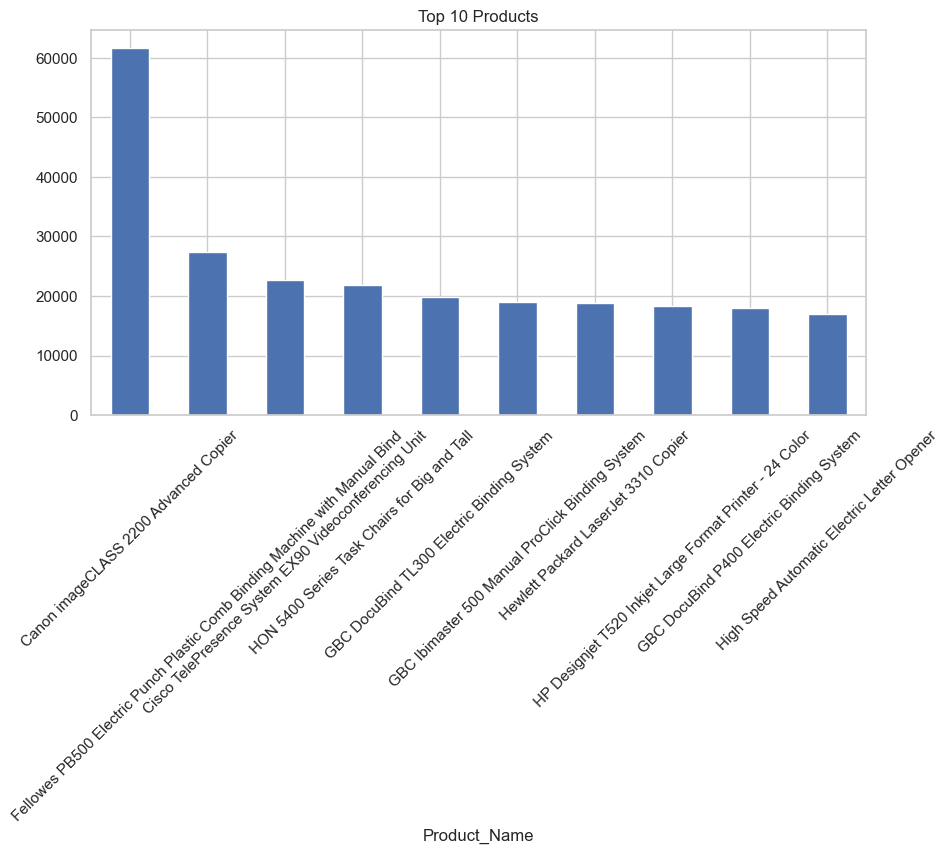

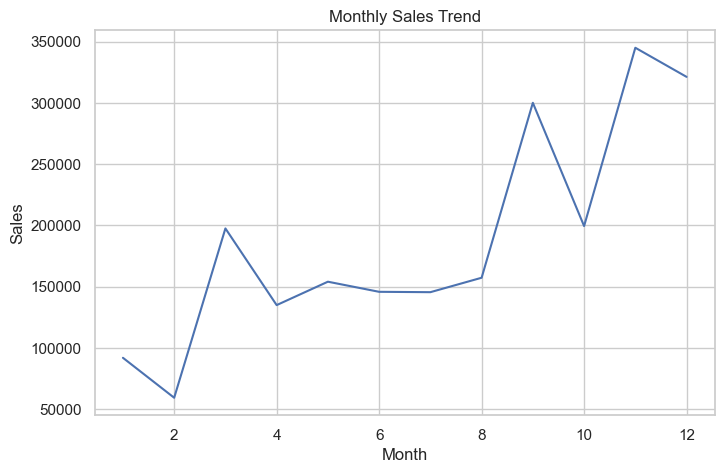


===== KEY INSIGHTS =====
1. Region with highest sales: West
2. Country generating most traffic: United States
3. High demand products identified from top 10 list
4. Certain months show peak sales trends
5. Customer age distribution helps target audience

Final Dataset Preview:


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Month
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,10


In [2]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# ==============================
# STEP 2: LOAD DATASETS
# ==============================

df1 = pd.read_csv("ecommerce_customer_data_large.csv")
df2 = pd.read_csv("superstore_final_dataset.csv", encoding='latin1')
df3 = pd.read_csv("traffic.csv", encoding='latin1')

# ==============================
# STEP 3: CLEAN DATA
# ==============================

# Customer Data
df1 = df1.dropna().drop_duplicates()

# Sales Data
df2 = df2.dropna().drop_duplicates()
df2["Order_Date"] = pd.to_datetime(df2["Order_Date"], dayfirst=True)

# Website Traffic Data
df3 = df3.dropna().drop_duplicates()
df3["date"] = pd.to_datetime(df3["date"], errors='coerce')

# ==============================
# STEP 4: KPI CALCULATIONS
# ==============================

total_revenue = df2["Sales"].sum()
avg_order_value = df2["Sales"].mean()
top_region = df2.groupby("Region")["Sales"].sum().idxmax()
top_country = df3["country"].value_counts().idxmax()

print("===== KEY KPIs =====")
print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)
print("Top Sales Region:", top_region)
print("Top Traffic Country:", top_country)

# ==============================
# STEP 5: SALES BY REGION
# ==============================

region_sales = df2.groupby("Region")["Sales"].sum()

plt.figure(figsize=(8,5))
region_sales.sort_values().plot(kind="barh")
plt.title("Sales by Region")
plt.xlabel("Sales")
plt.ylabel("Region")
plt.show()

# ==============================
# STEP 6: SALES BY CATEGORY
# ==============================

category_sales = df2.groupby("Category")["Sales"].sum()

plt.figure(figsize=(6,6))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%')
plt.title("Sales Distribution by Category")
plt.show()

# ==============================
# STEP 7: CUSTOMER AGE DISTRIBUTION
# ==============================

plt.figure(figsize=(8,5))
sns.histplot(df1["Age"], bins=20)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.show()

# ==============================
# STEP 8: WEBSITE TRAFFIC (COUNTRIES)
# ==============================

traffic_country = df3["country"].value_counts().head(10)

plt.figure(figsize=(8,5))
traffic_country.sort_values().plot(kind="barh")
plt.title("Top 10 Traffic Countries")
plt.xlabel("Users")
plt.show()

# ==============================
# STEP 9: TOP PRODUCTS
# ==============================

top_products = df2.groupby("Product_Name")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Products")
plt.xticks(rotation=45)
plt.show()

# ==============================
# STEP 10: TIME ANALYSIS
# ==============================

df2["Month"] = df2["Order_Date"].dt.month
monthly_sales = df2.groupby("Month")["Sales"].sum()

plt.figure(figsize=(8,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# ==============================
# STEP 11: INSIGHTS
# ==============================

print("\n===== KEY INSIGHTS =====")
print("1. Region with highest sales:", top_region)
print("2. Country generating most traffic:", top_country)
print("3. High demand products identified from top 10 list")
print("4. Certain months show peak sales trends")
print("5. Customer age distribution helps target audience")

# ==============================
# STEP 12: FINAL OUTPUT
# ==============================

print("\nFinal Dataset Preview:")
display(df2.head())